In [1]:
import jax
from jax import grad, jit

import jax.numpy as jnp

import numpy as np
import random

import matplotlib.pyplot as plt
from tqdm import tqdm


import optax

In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.reshape(-1, 28, 28)  # optional: reshape from (70000, 784) to (70000, 28, 28)

# Split if needed
X_train, y_train = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


X_train = (X_train - 128)/128

X_test = (X_test - 128)/128

X_train.min(),X_train.max()

(np.float64(-1.0), np.float64(0.9921875))

In [3]:
def encoder(params, X):
    for p in params:
        X = X @ p
        X = jax.nn.relu(X)
    return X
    
def decoder(params, X):
    for i,p in enumerate(params):
        X = X @ p
        if i == len(params) - 1:
            X = jnp.tanh(X)
        else:
            X = jax.nn.relu(X)
    return X

In [4]:
# if we do initally scale the parameters by a small value, the autoencoder does not converge, scale by 0.1 -> INITIALIZATION IS CRUCIAL, 
# otherwise, we may think the autoencoder is not working
def get_params(inputsize, layersizes : list, outputsize, scale):
    params = [np.random.randn(inputsize, layersizes[0])*scale]
    
    for i in range(0, len(layersizes)-1):
        params.append(np.random.randn(layersizes[i], layersizes[i+1])*scale)    

    params += [np.random.randn(layersizes[-1],outputsize)*scale]
    return params
        
        

In [5]:
# if we do initally scale the parameters by a small value, the autoencoder does not converge, scale by 0.1 -> INITIALIZATION IS CRUCIAL, 
# otherwise, we may think the autoencoder is not working
encoder_params = get_params( X_train.shape[1],[500], 100, scale=0.1)
for p in encoder_params:
    print(p.shape)

latent = encoder(encoder_params, X_train)
print("\n",latent.shape)

(784, 500)
(500, 100)

 (60000, 100)


In [6]:
# if we do initally scale the parameters by a small value, the autoencoder does not converge, scale by 0.1 -> INITIALIZATION IS CRUCIAL, 
# otherwise, we may think the autoencoder is not working
decoder_params = get_params(100,[500], X_train.shape[1], scale=0.1)
for p in decoder_params:
    print(p.shape)

out = decoder(decoder_params, latent)
print("\n",out.shape)

(100, 500)
(500, 784)

 (60000, 784)


In [10]:
def autoencoder(params, X):
    encparams, decparams = params
    
    latent = encoder(encparams, X)
    Xhat = decoder(decparams, latent)

    return Xhat

params = encoder_params, decoder_params
autoencoder(params, X_train).shape

(60000, 784)

In [11]:
@jit
def lossfn(params, X):
    Xhat = autoencoder(params,X)
    loss = jnp.mean((Xhat - X)**2)
    return loss

In [13]:
lossgrad = jit(grad(lossfn))



encoder_params = get_params( X_train.shape[1],[500], 100, scale=0.1)
decoder_params = get_params(100,[500], X_train.shape[1], scale=0.1)


params = encoder_params , decoder_params

# USING AMS GRAD SEEMS TO BE CRITICAL TO GET LOSS BELOW 0.5
optimizer = optax.amsgrad(learning_rate=1e-3)
state = optimizer.init(params)


EPOCHS  = 30



pbar = tqdm(range(EPOCHS), colour='blue')

for _ in pbar:
    BSIZE = 1000 if _ < 2*EPOCHS/3 else 5000
    batches = range(0,X_train.shape[0],BSIZE)
    for bstart in batches:
        xbatch = X_train[bstart: bstart+BSIZE]
        loss = lossfn(params, xbatch)

        gradient = lossgrad(params, xbatch)
        updates, state = optimizer.update(gradient, state, params)
        params = optax.apply_updates(params, updates)

        pbar.set_postfix_str(f"loss:{loss*100:.3f}%")
        

100%|██████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:06<00:00,  4.42it/s, loss:5.599%]


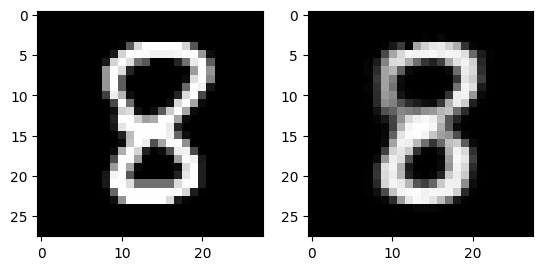

In [16]:
idx = random.randint(0,X_train.shape[0])

plt.subplot(1,2,1)
plt.imshow(X_train[idx].reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(autoencoder(params,X_train)[idx].reshape(28,28), cmap='gray')

In [17]:
random20 = [random.randint(0,X_test.shape[0]) for i in range(20)]

X_test_random = X_test[random20]

X_test_reconstruction = autoencoder(params, X_test_random)

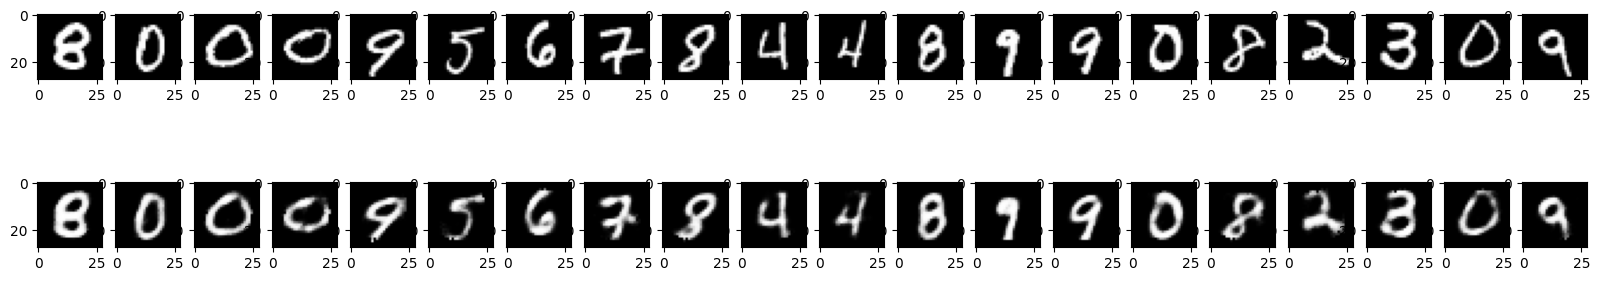

In [18]:
plt.figure(figsize=(20,4))
for i in range(20):
    x,y = X_test_random[i], X_test_reconstruction[i]

    x,y = x.reshape(28,28), y.reshape(28,28)

    plt.subplot(2,20,1+i)
    plt.imshow(x, cmap='gray')

    plt.subplot(2,20,21+i)
    plt.imshow(y, cmap='gray')
    

Reconstruction Error:  4.28%


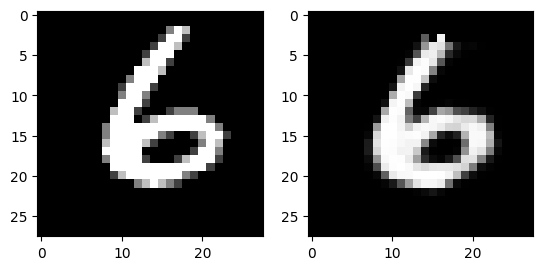

In [27]:
CRED    = '\33[31m'
CGREEN  = '\33[32m'
CEND      = '\33[0m'
CBOLD     = '\33[1m'

random_idx = random.randint(0,X_test.shape[0])
xtest = X_test[random_idx:random_idx+1]
ytest = autoencoder(params, xtest)

plt.subplot(1,2,1)
plt.imshow(xtest.reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(ytest.reshape(28,28), cmap='gray')

print(f"Reconstruction Error: {CBOLD}{CGREEN} {lossfn(params, xtest)*100:.2f}%")

Reconstruction Error:   14.85%


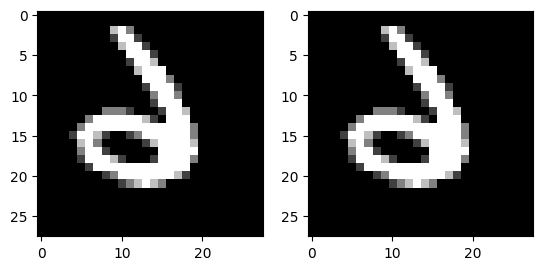

In [28]:
# FLIPPING THE IMAGE AND THEN GET RECONSTRUCTION ERROR AGAIN


xtest_flipped = xtest.reshape(28,28)[:,::-1]
ytest_flipped = autoencoder(params, xtest_flipped.reshape(-1))

plt.subplot(1,2,1)
plt.imshow(xtest_flipped, cmap='gray')

plt.subplot(1,2,2)
plt.imshow(xtest_flipped.reshape(28,28), cmap='gray')


print(f"Reconstruction Error: {CBOLD} {CRED} {lossfn(params, xtest_flipped.reshape(-1))*100:.2f}%")


In [ ]:
# COMMENTS

# 1. Reconstruction Error is higher when Flipped/Rotated

# We can detect anomaly by looking at the how many standard deviations away is the reconstruction error of an input and then use a suitable threshold to mark as anomalous if beyond that threshold